# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Sun May  3 19:55:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.97                 Driver Version: 555.97         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650 Ti   WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   55C    P8              4W /   50W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code


2.7.1+cu118


## 1. What are 3 areas in industry where computer vision is currently being used?

1. Healthcare – detecting diseases from X-rays, MRIs, CT scans
2. Autonomous vehicles – object detection, lane tracking, pedestrian detection
3. Retail – cashier-less stores, product recognition, inventory tracking

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

Overfitting is when a machine learning model learns the training data too well, including noise, and performs poorly on unseen data.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

1. Regularization (L1/L2)
Adds penalty to large weights to simplify the model and avoid memorization.
2. Dropout
Randomly turns off neurons during training to improve generalization.
3. Data Augmentation
Creates more training data by flipping, rotating, or modifying images

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

Done

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [3]:
from torchvision import datasets, transforms

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.35MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 124kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 763kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.27MB/s]


## 6. Visualize at least 5 different samples of the MNIST training dataset.

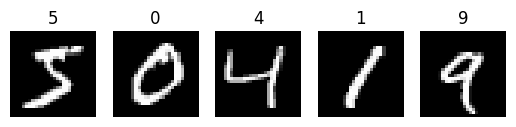

In [4]:
import matplotlib.pyplot as plt

for i in range(5):
    image, label = train_data[i]
    plt.subplot(1, 5, i+1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(label)
    plt.axis(False)
plt.show()

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [5]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [6]:
import torch.nn as nn

class TinyVGG(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(1, 10, 3),
            nn.ReLU(),
            nn.Conv2d(10, 10, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(10, 10, 3),
            nn.ReLU(),
            nn.Conv2d(10, 10, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(10*4*4, 10)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        return self.classifier(x)

model = TinyVGG()

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [7]:
import torch
from torch import optim

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} loss: {loss.item()}")

Epoch 1 loss: 0.09470725804567337
Epoch 2 loss: 0.007672493811696768
Epoch 3 loss: 0.02683529257774353
Epoch 4 loss: 0.016230911016464233
Epoch 5 loss: 0.06705150008201599


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

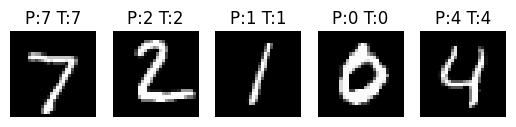

In [8]:
model.eval()

with torch.no_grad():
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)
    preds = model(images).argmax(dim=1)

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.title(f"P:{preds[i].item()} T:{labels[i].item()}")
    plt.axis(False)
plt.show()

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

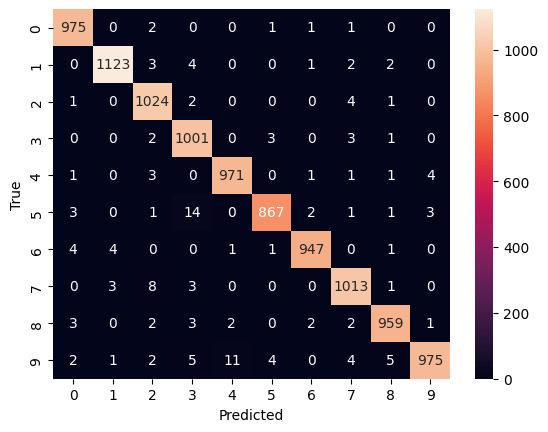

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [11]:
import torch
import torch.nn as nn

x = torch.randn(1, 3, 64, 64)

conv_small = nn.Conv2d(3, 6, kernel_size=3)
conv_large = nn.Conv2d(3, 6, kernel_size=7)

print(conv_small(x).shape)
print(conv_large(x).shape)

torch.Size([1, 6, 62, 62])
torch.Size([1, 6, 58, 58])


## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

100%|██████████| 26.4M/26.4M [00:08<00:00, 2.96MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 196kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


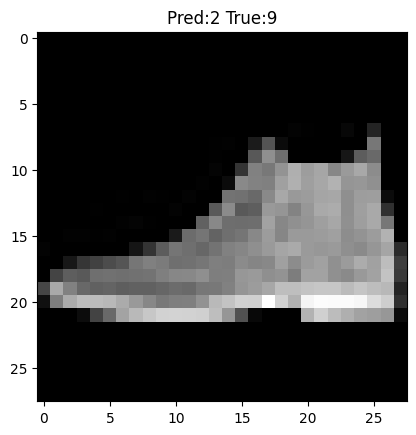

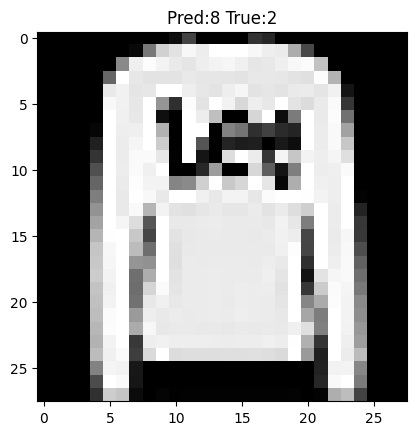

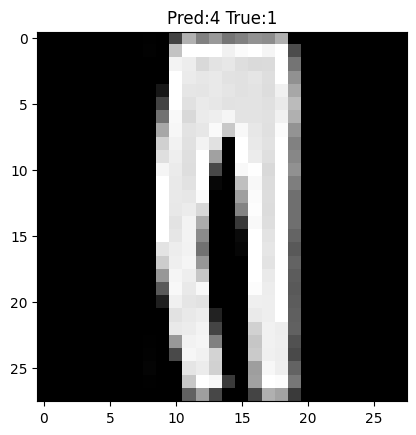

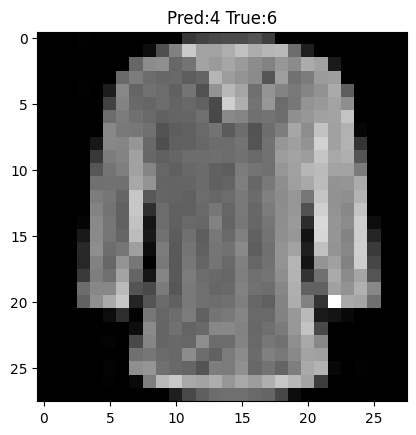

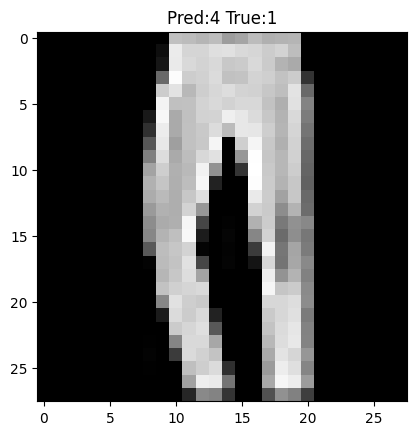

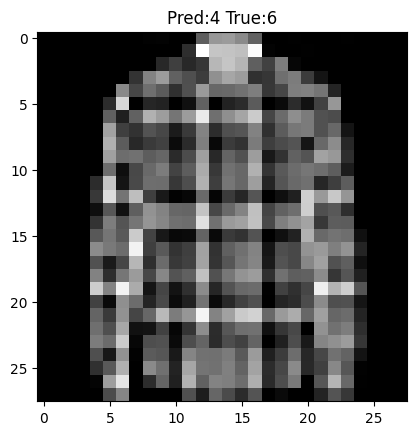

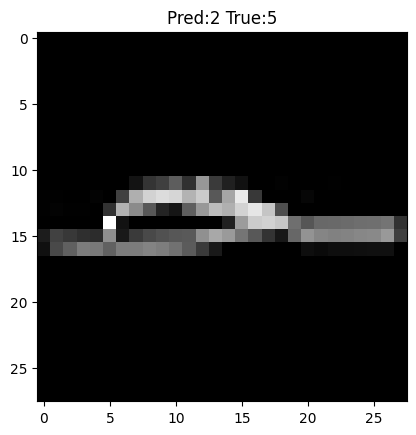

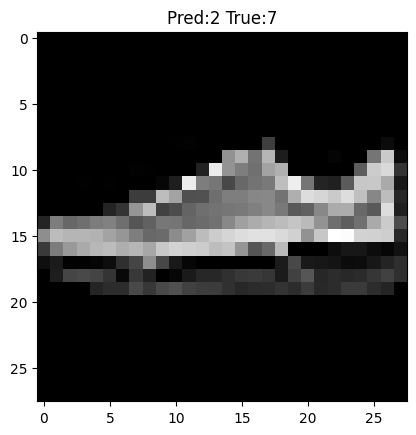

In [12]:
from torchvision.datasets import FashionMNIST

fashion_test = FashionMNIST(root="data", train=False, download=True, transform=transforms.ToTensor())
fashion_loader = DataLoader(fashion_test, batch_size=32)

model.eval()

images, labels = next(iter(fashion_loader))
images, labels = images.to(device), labels.to(device)

preds = model(images).argmax(dim=1)

for i in range(10):
    if preds[i] != labels[i]:
        plt.imshow(images[i].cpu().squeeze(), cmap="gray")
        plt.title(f"Pred:{preds[i].item()} True:{labels[i].item()}")
        plt.show()